# 02 — Do the 95% intervals cover 95% of the time?

500 synthetic users, each with a known TDEE. At several horizons we compare four estimators and check how
often the true TDEE falls inside the reported 95% interval:

| estimator | what it is |
|---|---|
| `kalman_prior` | this model, started from a formula-based guess that is off by N(0, 300) kcal |
| `kalman_vague` | this model with an uninformative prior (sd 2000 kcal) — data only |
| `ols_raw` | TDEE = mean intake − slope × 7700, OLS on raw readings, textbook CI |
| `ols_raw_nw` | same regression, Newey-West (HAC) standard errors — the usual fix for autocorrelated residuals |
| `ols_ema` | OLS on an EMA-smoothed weight (half-life 5 d), textbook CI — a common app approach |

The simulator adds things the filter does not model: water spikes (2%/day, +1.5 kg), missing days.

In [1]:
import sys
sys.path.insert(0, "../src")
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tdee import DEFAULT, Params, run, summarize, ols_tdee, SimConfig, simulate_user
from tdee.baselines import newey_west_lags
from tdee.plotting import set_style, SERIES, INK_2
set_style()

In [2]:
DAYS = [14, 21, 28, 42, 56, 83]
VAGUE = replace(DEFAULT, prior_t_sd=2000.0)
METHODS = ["kalman_prior", "kalman_vague", "ols_raw", "ols_raw_nw", "ols_ema"]


def evaluate(cfg, n_users=500, seed=0, filter_params=DEFAULT, breaks_from_truth=False):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n_users):
        inp, tr = simulate_user(cfg, rng)
        breaks = (inp["date"].iloc[cfg.step_day],) if (breaks_from_truth and cfg.step_day) else ()
        prior = tr["T"].iloc[0] + rng.normal(0, 300)
        hk, _ = run(inp, filter_params, prior, breaks)
        hv, _ = run(inp, replace(filter_params, prior_t_sd=2000.0), 2500.0, breaks)
        for day in DAYS:
            T = tr["T"].iloc[day]
            rows += [("kalman_prior", day, hk["T"].iloc[day] - T, 1.96 * hk["T_sd"].iloc[day]),
                     ("kalman_vague", day, hv["T"].iloc[day] - T, 1.96 * hv["T_sd"].iloc[day])]
            win = inp.iloc[: day + 1]
            obs = win.dropna(subset=["weight_kg"])
            im = win["intake"].iloc[:day].mean()
            for name, hl, lags in (("ols_raw", None, None), ("ols_ema", 5.0, None),
                                   ("ols_raw_nw", None, newey_west_lags(len(obs)))):
                r = ols_tdee(obs["date"], obs["weight_kg"], im, hl, lags)
                rows.append((name, day, r["tdee"] - T, r["tdee_ci95"]))
    df = pd.DataFrame(rows, columns=["method", "day", "err", "ci"])
    df["covered"] = df["err"].abs() <= df["ci"]
    return df.groupby(["method", "day"]).agg(
        coverage=("covered", "mean"), ci_halfwidth=("ci", "mean"),
        rmse=("err", lambda e: float(np.sqrt((e ** 2).mean())))).reset_index()


def plot(res, title, path=None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for m, c in zip(METHODS, SERIES):
        r = res[res["method"] == m]
        axes[0].plot(r["day"], 100 * r["coverage"], marker="o", ms=4, color=c, label=m)
        axes[1].plot(r["day"], r["ci_halfwidth"], marker="o", ms=4, color=c, label=m)
        axes[2].plot(r["day"], r["rmse"], marker="o", ms=4, color=c, label=m)
    axes[0].axhline(95, color=INK_2, ls=":", lw=1)
    axes[0].set_ylim(0, 100)
    axes[0].set_title("Actual coverage of the '95%' CI (%)")
    axes[1].set_title("Reported CI half-width (kcal)")
    axes[2].set_title("RMSE of the point estimate (kcal)")
    for ax in axes:
        ax.set_xlabel("days of data")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(METHODS), bbox_to_anchor=(0.5, 0.0))
    fig.suptitle(title, x=0.01, ha="left", fontsize=11, fontweight="semibold")
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    if path:
        fig.savefig(path, dpi=130)

## Baseline: simulator matches the model's noise structure (plus spikes)

method,kalman_prior,kalman_vague,ols_ema,ols_raw,ols_raw_nw
day,,,,,
14,0.95,0.92,0.38,0.64,0.57
21,0.94,0.91,0.31,0.61,0.61
28,0.93,0.91,0.28,0.62,0.68
42,0.93,0.91,0.31,0.59,0.70
56,0.93,0.92,0.32,0.55,0.68
83,0.93,0.92,0.26,0.49,0.66


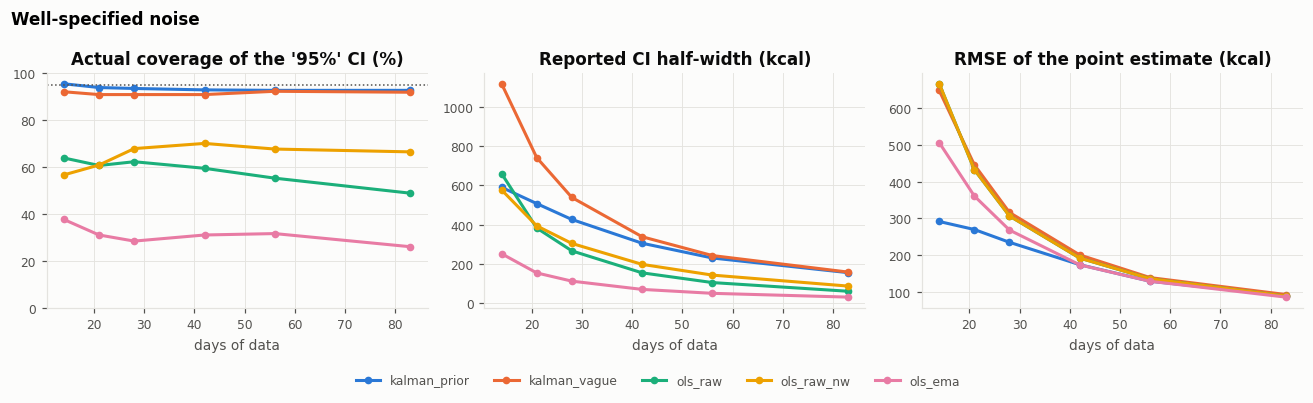

In [3]:
base = evaluate(SimConfig())
plot(base, "Well-specified noise", "../figures/coverage.png")
base.pivot(index="day", columns="method", values="coverage").round(2)

In [4]:
base.pivot(index="day", columns="method", values="rmse").round(0)

method,kalman_prior,kalman_vague,ols_ema,ols_raw,ols_raw_nw
day,,,,,
14,292.0,649.0,507.0,668.0,668.0
21,270.0,446.0,361.0,433.0,433.0
28,235.0,316.0,268.0,307.0,307.0
42,174.0,200.0,173.0,192.0,192.0
56,128.0,138.0,128.0,135.0,135.0
83,89.0,92.0,85.0,88.0,88.0


## Why not just Newey-West?

Newey-West is the standard correction when regression residuals are autocorrelated (overlapping returns,
persistent errors): it estimates the long-run variance from the residual autocovariances instead of assuming
independence. Here it barely helps. With 10 to 65 readings and water persistence around 0.77, the HAC variance
estimator is strongly biased downward: the sample is too short to see the correlation it is supposed to correct
(a known small-sample result; fixed-b asymptotics à la Kiefer-Vogelsang widen the critical values but remain
approximate at this size). Correcting the standard errors is not enough; the dependence has to be modelled.

## Robustness 1 — the filter's noise parameters are wrong

Real water is noisier and more persistent than the filter assumes (sigma_h 1.0 vs 0.75, phi 0.85 vs 0.77),
with more frequent spikes.

method,kalman_prior,kalman_vague,ols_ema,ols_raw,ols_raw_nw
day,,,,,
14,0.92,0.79,0.32,0.57,0.51
21,0.88,0.76,0.29,0.50,0.53
28,0.83,0.75,0.26,0.49,0.56
42,0.80,0.75,0.29,0.49,0.62
56,0.77,0.77,0.27,0.49,0.64
83,0.77,0.76,0.29,0.46,0.65


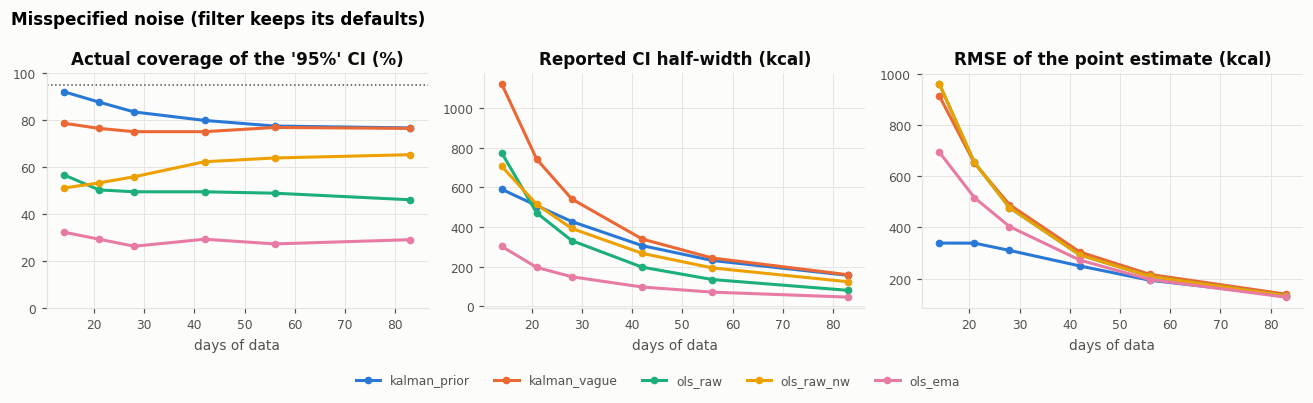

In [5]:
mis = evaluate(SimConfig(sigma_h=1.0, phi=0.85, spike_prob=0.05), seed=1)
plot(mis, "Misspecified noise (filter keeps its defaults)", "../figures/coverage_misspecified.png")
mis.pivot(index="day", columns="method", values="coverage").round(2)

## Robustness 2 — a TDEE step change (+300 kcal at day 42)

With a small TDEE random walk (5 kcal/day), the filter adapts slowly to an abrupt change unless it is told a
regime change happened (`regime_breaks`), in which case TDEE uncertainty is re-inflated at that date.

In [6]:
step = SimConfig(step_day=42, step_kcal=300.0)
unknown = evaluate(step, seed=2)
known = evaluate(step, seed=2, breaks_from_truth=True)
cmp = pd.concat([unknown.assign(breaks="unknown"), known.assign(breaks="declared")])
cmp[cmp["method"] == "kalman_prior"].pivot(index="day", columns="breaks", values=["coverage", "rmse"]).round(2)

coverage             rmse        
breaks declared unknown declared unknown
day                                     
14         0.95    0.95   285.31  285.31
21         0.94    0.94   264.10  264.10
28         0.92    0.92   241.60  241.60
42         0.91    0.42   380.82  380.82
56         0.91    0.35   283.99  311.42
83         0.91    0.36   150.18  204.62